# 62 - SigLIP 2 テキスト検索の評価

## 概要
SigLIP 2 (`google/siglip2-base-patch16-224`) を使ったテキストによる画像検索の性能を評価する。
SigLIP 1 (実験23) および CLIP-L (実験22) との比較を行う。

## 評価の観点
1. **テキストクエリで適切な画像が検索されるか？** → Precision@K, MRR
2. **英語 vs 日本語クエリ** → 言語による性能差
3. **3モデル比較**: SigLIP 2 vs SigLIP 1 vs CLIP-L

## SigLIP 2 の特徴
- Gemma BPE トークナイザー（256K語彙）— 日本語の改善が期待される
- WebLI データセット（109言語）で訓練
- 拡張された訓練目的関数

## 前提
- Notebook 61 で SigLIP 2 の画像埋め込みが DuckDB に保存済みであること

In [1]:
import json
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from image_vector_poc import SigLIP2Embedder

## 1. データの読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
MODEL_NAME = "google/siglip2-base-patch16-224"

# 画像カタログの読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_query = """
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY id
"""
catalog_df = conn.execute(catalog_query).fetchdf()

print(f"Total images: {len(catalog_df)}")
print(f"\nCategories:")
category_counts = catalog_df['category'].value_counts().to_dict()
for cat, count in category_counts.items():
    print(f"  {cat}: {count}")

Total images: 378

Categories:
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


In [3]:
# SigLIP 2 の埋め込みを読み込み
embeddings_query = """
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
"""
embeddings_df = conn.execute(embeddings_query, [MODEL_NAME]).fetchdf()
conn.close()

print(f"Loaded {len(embeddings_df)} embeddings")

if len(embeddings_df) == 0:
    raise ValueError(f"No embeddings found for {MODEL_NAME}. Please run notebook 61 first.")

# 埋め込みをNumPy配列に変換
image_embeddings = np.array(embeddings_df['embedding'].tolist(), dtype=np.float32)
print(f"Embeddings shape: {image_embeddings.shape}")

# ノルムの確認
norms = np.linalg.norm(image_embeddings, axis=1)
print(f"Embedding norms - Mean: {norms.mean():.4f}, Min: {norms.min():.4f}, Max: {norms.max():.4f}")

# 正規化（コサイン類似度用）
norms_for_norm = np.clip(norms.reshape(-1, 1), 1e-8, None)
image_embeddings_normalized = image_embeddings / norms_for_norm

# カテゴリリスト
categories = catalog_df['category'].tolist()
category_names = list(category_counts.keys())

Loaded 378 embeddings
Embeddings shape: (378, 768)
Embedding norms - Mean: 1.0000, Min: 1.0000, Max: 1.0000


## 2. SigLIP 2 モデルの読み込み（テキスト埋め込み用）

In [4]:
embedder = SigLIP2Embedder(model_name=MODEL_NAME, device="cuda")
print(f"Model loaded: {embedder.model_name}")
print(f"Embedding dimension: {embedder.embedding_dim}")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model loaded: google/siglip2-base-patch16-224
Embedding dimension: 768


## 3. テストクエリの定義

実験22/23と同じ18クエリを使用する。

In [5]:
# テストクエリの定義（実験22/23と同じ）
test_queries = [
    # カテゴリ固有のクエリ（英語）
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "type": "specific", "lang": "en"},
    # 一般的なクエリ（英語）
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    # 日本語クエリ
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "type": "specific", "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "ja"},
]

print(f"Total test queries: {len(test_queries)}")
print(f"  English: {sum(1 for q in test_queries if q['lang'] == 'en')}")
print(f"  Japanese: {sum(1 for q in test_queries if q['lang'] == 'ja')}")

Total test queries: 18
  English: 12
  Japanese: 6


## 4. テキスト検索の実行と評価

In [6]:
def search_by_text(query: str, embedder, image_embeddings: np.ndarray, top_k: int = 20):
    """テキストクエリで画像を検索する。"""
    text_embedding = embedder.embed_text(query)
    text_embedding = text_embedding / np.linalg.norm(text_embedding)
    similarities = np.dot(image_embeddings, text_embedding)
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]
    return top_indices, top_scores


def evaluate_query(query_info: dict, embedder, image_embeddings: np.ndarray,
                   categories: list, k_values: list = [1, 5, 10, 20]):
    """単一のクエリを評価する。"""
    query = query_info["query"]
    expected_cats = query_info["expected_categories"]
    
    max_k = max(k_values)
    indices, scores = search_by_text(query, embedder, image_embeddings, top_k=max_k)
    result_categories = [categories[idx] for idx in indices]
    is_relevant = [cat in expected_cats for cat in result_categories]
    
    # Precision@K
    precision_at_k = {}
    for k in k_values:
        relevant_in_k = sum(is_relevant[:k])
        precision_at_k[f"P@{k}"] = relevant_in_k / k
    
    # MRR
    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break
    
    # Hit Rate@K
    hit_rate_at_k = {}
    for k in k_values:
        hit_rate_at_k[f"HR@{k}"] = 1.0 if any(is_relevant[:k]) else 0.0
    
    return {
        "query": query,
        "expected_categories": expected_cats,
        "type": query_info["type"],
        "lang": query_info["lang"],
        "top_results": result_categories[:10],
        "top_scores": scores[:10].tolist(),
        **precision_at_k,
        "MRR": mrr,
        **hit_rate_at_k,
    }

In [7]:
# 全クエリの評価
print("Evaluating all queries...")
results = []

for query_info in test_queries:
    result = evaluate_query(query_info, embedder, image_embeddings_normalized, categories)
    results.append(result)
    print(f"  {query_info['query'][:40]:40s} | P@1={result['P@1']:.2f} | P@10={result['P@10']:.2f} | MRR={result['MRR']:.2f}")

print("\nEvaluation complete!")

Evaluating all queries...
  a park with trees and nature             | P@1=0.00 | P@10=0.30 | MRR=0.25
  village park with greenery               | P@1=0.00 | P@10=0.10 | MRR=0.14
  night cityscape Tokyo                    | P@1=1.00 | P@10=1.00 | MRR=1.00
  city lights at night                     | P@1=1.00 | P@10=1.00 | MRR=1.00
  Python conference presentation           | P@1=1.00 | P@10=1.00 | MRR=1.00
  conference hall with audience            | P@1=1.00 | P@10=1.00 | MRR=1.00
  speaker giving a talk                    | P@1=1.00 | P@10=1.00 | MRR=1.00
  portrait photo of a person               | P@1=1.00 | P@10=0.70 | MRR=1.00
  outdoor nature scene                     | P@1=1.00 | P@10=0.90 | MRR=1.00
  urban night photography                  | P@1=1.00 | P@10=1.00 | MRR=1.00
  tech conference event                    | P@1=1.00 | P@10=1.00 | MRR=1.00
  people at an event                       | P@1=1.00 | P@10=1.00 | MRR=1.00
  公園の自然風景                                  | P@1=0

## 5. 結果サマリー

In [8]:
results_df = pd.DataFrame(results)

# 全体の平均
print("=" * 60)
print("Overall Results (SigLIP 2)")
print("=" * 60)

metric_cols = ["P@1", "P@5", "P@10", "P@20", "MRR", "HR@1", "HR@5", "HR@10"]
overall_means = results_df[metric_cols].mean()

for metric, value in overall_means.items():
    print(f"  {metric}: {value:.4f}")

Overall Results (SigLIP 2)
  P@1: 0.7222
  P@5: 0.7667
  P@10: 0.7389
  P@20: 0.7167
  MRR: 0.7919
  HR@1: 0.7222
  HR@5: 0.8889
  HR@10: 1.0000


In [9]:
# 言語別の結果
print("\n" + "=" * 60)
print("Results by Language")
print("=" * 60)

lang_results = results_df.groupby("lang")[metric_cols].mean()
display(lang_results.round(4))


Results by Language


,P@1,P@5,P@10,P@20,MRR,HR@1,HR@5,HR@10
lang,,,,,,,,
en,0.8333,0.8667,0.8333,0.8083,0.8661,0.8333,0.9167,1.0
ja,0.5000,0.5667,0.5500,0.5333,0.6435,0.5000,0.8333,1.0


In [10]:
# クエリタイプ別の結果
print("\n" + "=" * 60)
print("Results by Query Type")
print("=" * 60)

type_results = results_df.groupby("type")[metric_cols].mean()
display(type_results.round(4))


Results by Query Type


,P@1,P@5,P@10,P@20,MRR,HR@1,HR@5,HR@10
type,,,,,,,,
general,0.6667,0.7,0.7000,0.700,0.7269,0.6667,0.8333,1.0
specific,0.7500,0.8,0.7583,0.725,0.8244,0.7500,0.9167,1.0


## 6. 3モデル比較: SigLIP 2 vs SigLIP 1 vs CLIP-L

In [11]:
# 既存モデルの結果（Notebook 22/23 より）
clip_results = {
    "overall": {"P@1": 0.7778, "P@5": 0.8222, "P@10": 0.8000, "MRR": 0.8611, "HR@5": 0.9444},
    "en": {"P@1": 0.75, "P@10": 0.8583, "MRR": 0.875},
    "ja": {"P@1": 0.8333, "P@10": 0.6833, "MRR": 0.8333},
}

siglip1_results = {
    "overall": {"P@1": 0.7222, "P@5": 0.7556, "P@10": 0.7444, "MRR": 0.8194, "HR@5": 0.9444},
    "en": {"P@1": 0.75, "P@10": 0.8167, "MRR": 0.8264},
    "ja": {"P@1": 0.6667, "P@10": 0.6000, "MRR": 0.8056},
}

siglip2_results = {
    "overall": overall_means.to_dict(),
    "en": lang_results.loc["en"].to_dict() if "en" in lang_results.index else {},
    "ja": lang_results.loc["ja"].to_dict() if "ja" in lang_results.index else {},
}

# 全体性能比較
print("=" * 80)
print("3モデル比較: SigLIP 2 vs SigLIP 1 vs CLIP-L")
print("=" * 80)

print(f"\n{'指標':<10} {'SigLIP 1':>10} {'CLIP-L':>10} {'SigLIP 2':>10} {'S2 vs S1':>10} {'S2 vs CL':>10}")
print("-" * 62)
for metric in ["P@1", "P@5", "P@10", "MRR", "HR@5"]:
    s1 = siglip1_results["overall"].get(metric, 0)
    cl = clip_results["overall"].get(metric, 0)
    s2 = siglip2_results["overall"].get(metric, 0)
    d1 = s2 - s1
    d2 = s2 - cl
    print(f"{metric:<10} {s1:>10.4f} {cl:>10.4f} {s2:>10.4f} {d1:>+10.4f} {d2:>+10.4f}")

3モデル比較: SigLIP 2 vs SigLIP 1 vs CLIP-L

指標           SigLIP 1     CLIP-L   SigLIP 2   S2 vs S1   S2 vs CL
--------------------------------------------------------------
P@1            0.7222     0.7778     0.7222    +0.0000    -0.0556
P@5            0.7556     0.8222     0.7667    +0.0111    -0.0555
P@10           0.7444     0.8000     0.7389    -0.0055    -0.0611
MRR            0.8194     0.8611     0.7919    -0.0275    -0.0692
HR@5           0.9444     0.9444     0.8889    -0.0555    -0.0555


In [12]:
# 言語別の比較
print("\n" + "=" * 80)
print("言語別の比較")
print("=" * 80)

for lang, lang_name in [("en", "English"), ("ja", "Japanese")]:
    print(f"\n{lang_name}:")
    print(f"{'指標':<10} {'SigLIP 1':>10} {'CLIP-L':>10} {'SigLIP 2':>10} {'S2 vs S1':>10} {'S2 vs CL':>10}")
    print("-" * 62)
    for metric in ["P@1", "P@10", "MRR"]:
        s1 = siglip1_results[lang].get(metric, 0)
        cl = clip_results[lang].get(metric, 0)
        s2 = siglip2_results[lang].get(metric, 0)
        d1 = s2 - s1
        d2 = s2 - cl
        print(f"{metric:<10} {s1:>10.4f} {cl:>10.4f} {s2:>10.4f} {d1:>+10.4f} {d2:>+10.4f}")


言語別の比較

English:
指標           SigLIP 1     CLIP-L   SigLIP 2   S2 vs S1   S2 vs CL
--------------------------------------------------------------
P@1            0.7500     0.7500     0.8333    +0.0833    +0.0833
P@10           0.8167     0.8583     0.8333    +0.0166    -0.0250
MRR            0.8264     0.8750     0.8661    +0.0397    -0.0089

Japanese:
指標           SigLIP 1     CLIP-L   SigLIP 2   S2 vs S1   S2 vs CL
--------------------------------------------------------------
P@1            0.6667     0.8333     0.5000    -0.1667    -0.3333
P@10           0.6000     0.6833     0.5500    -0.0500    -0.1333
MRR            0.8056     0.8333     0.6435    -0.1621    -0.1898


## 7. 可視化

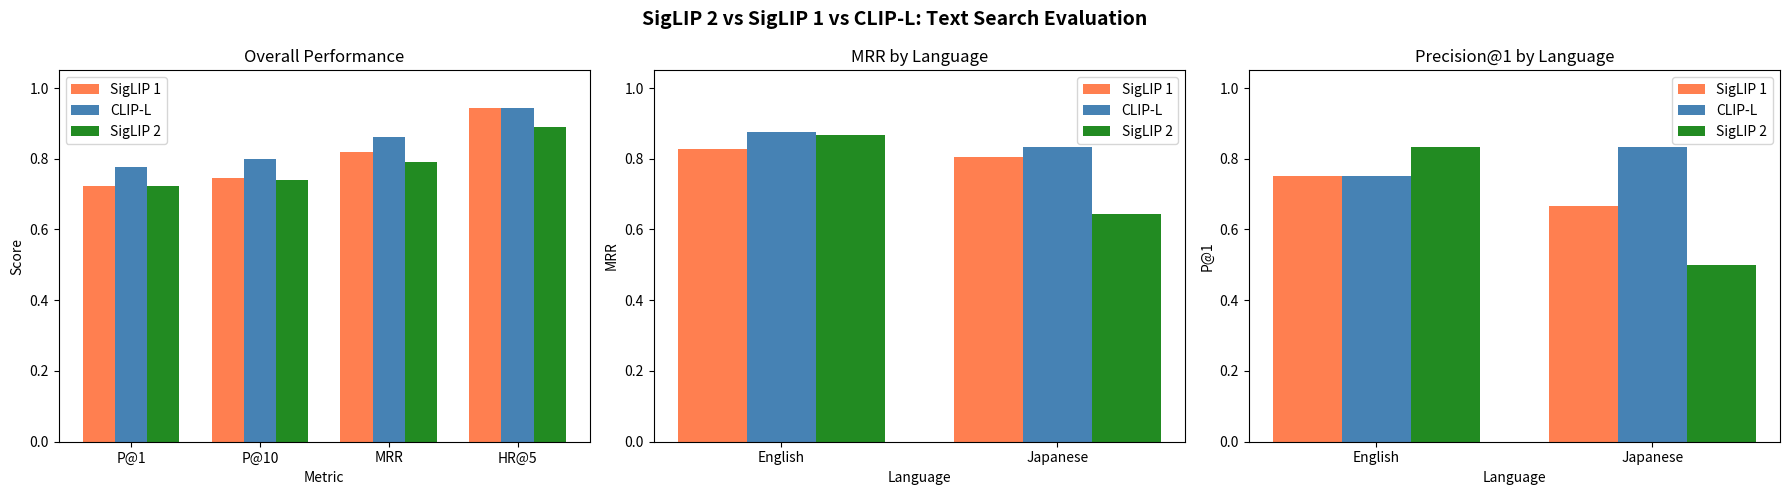

Saved: data/siglip2_text_search_comparison.png


In [13]:
# 3モデル比較のバーチャート
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ["SigLIP 1", "CLIP-L", "SigLIP 2"]
colors = ["coral", "steelblue", "forestgreen"]

# 全体性能比較
ax = axes[0]
metrics = ["P@1", "P@10", "MRR", "HR@5"]
x = np.arange(len(metrics))
width = 0.25

for i, (model, color) in enumerate(zip(models, colors)):
    if model == "SigLIP 1":
        values = [siglip1_results["overall"].get(m, 0) for m in metrics]
    elif model == "CLIP-L":
        values = [clip_results["overall"].get(m, 0) for m in metrics]
    else:
        values = [siglip2_results["overall"].get(m, 0) for m in metrics]
    ax.bar(x + (i - 1) * width, values, width, label=model, color=color)

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Overall Performance")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.05)

# 言語別 MRR
ax = axes[1]
langs = ["English", "Japanese"]
x = np.arange(len(langs))

for i, (model, color) in enumerate(zip(models, colors)):
    if model == "SigLIP 1":
        values = [siglip1_results["en"]["MRR"], siglip1_results["ja"]["MRR"]]
    elif model == "CLIP-L":
        values = [clip_results["en"]["MRR"], clip_results["ja"]["MRR"]]
    else:
        values = [siglip2_results["en"].get("MRR", 0), siglip2_results["ja"].get("MRR", 0)]
    ax.bar(x + (i - 1) * width, values, width, label=model, color=color)

ax.set_xlabel("Language")
ax.set_ylabel("MRR")
ax.set_title("MRR by Language")
ax.set_xticks(x)
ax.set_xticklabels(langs)
ax.legend()
ax.set_ylim(0, 1.05)

# 言語別 P@1
ax = axes[2]

for i, (model, color) in enumerate(zip(models, colors)):
    if model == "SigLIP 1":
        values = [siglip1_results["en"]["P@1"], siglip1_results["ja"]["P@1"]]
    elif model == "CLIP-L":
        values = [clip_results["en"]["P@1"], clip_results["ja"]["P@1"]]
    else:
        values = [siglip2_results["en"].get("P@1", 0), siglip2_results["ja"].get("P@1", 0)]
    ax.bar(x + (i - 1) * width, values, width, label=model, color=color)

ax.set_xlabel("Language")
ax.set_ylabel("P@1")
ax.set_title("Precision@1 by Language")
ax.set_xticks(x)
ax.set_xticklabels(langs)
ax.legend()
ax.set_ylim(0, 1.05)

plt.suptitle("SigLIP 2 vs SigLIP 1 vs CLIP-L: Text Search Evaluation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/siglip2_text_search_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/siglip2_text_search_comparison.png")

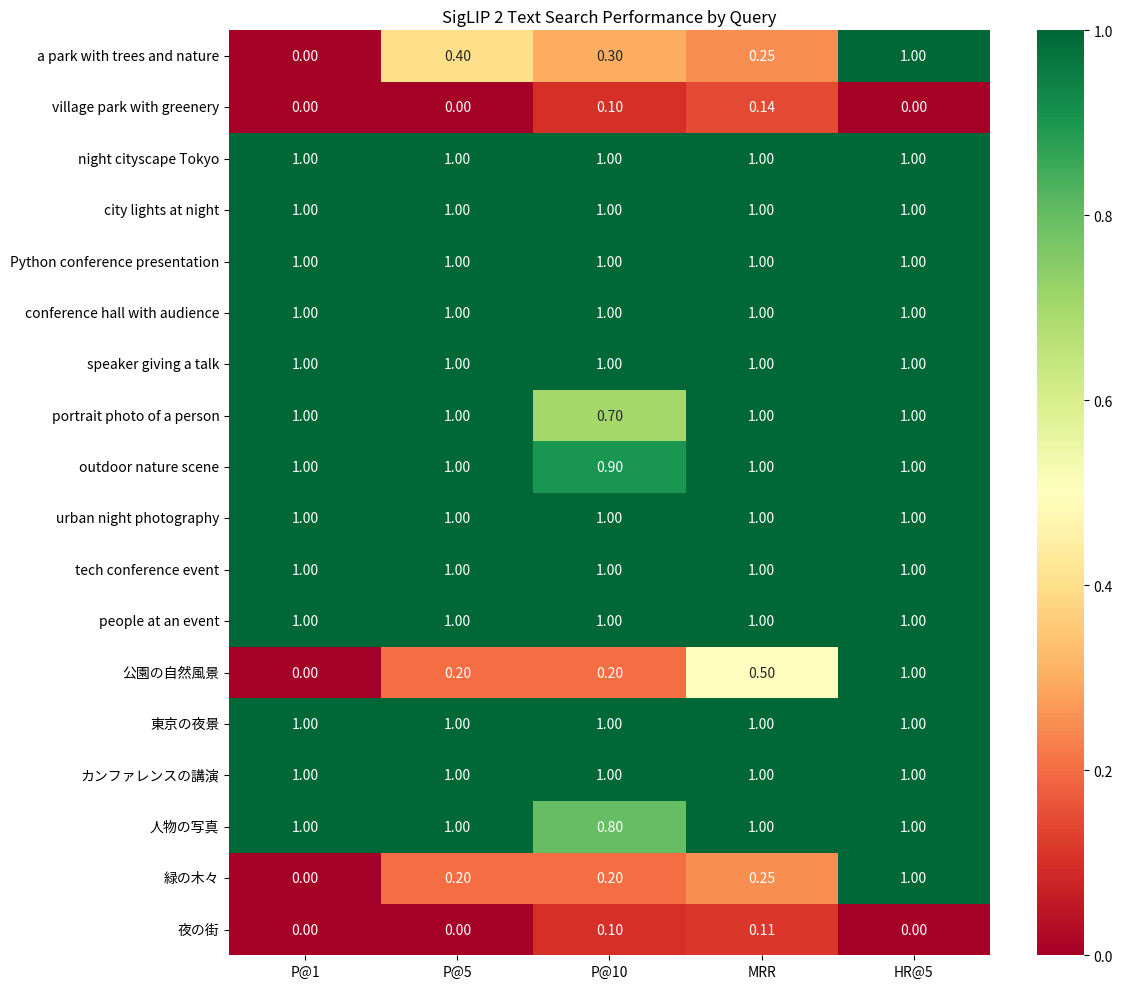

Saved: data/siglip2_text_search_heatmap.png


In [14]:
# 各クエリの結果をヒートマップで表示
fig, ax = plt.subplots(figsize=(12, 10))

query_labels = [f"{r['query'][:30]}..." if len(r['query']) > 30 else r['query']
                for r in results]

heatmap_data = results_df[["P@1", "P@5", "P@10", "MRR", "HR@5"]].values

sns.heatmap(
    heatmap_data,
    xticklabels=["P@1", "P@5", "P@10", "MRR", "HR@5"],
    yticklabels=query_labels,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    ax=ax,
)
ax.set_title("SigLIP 2 Text Search Performance by Query")

plt.tight_layout()
plt.savefig("../data/siglip2_text_search_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/siglip2_text_search_heatmap.png")

## 8. 検索結果の可視化

In [15]:
def visualize_search_results(query: str, expected_categories: list, k: int = 10):
    """テキスト検索結果を可視化する。"""
    indices, scores = search_by_text(query, embedder, image_embeddings_normalized, top_k=k)
    
    n_cols = 5
    n_rows = (k + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
    axes = axes.flatten()
    
    correct_count = 0
    for i, (idx, score) in enumerate(zip(indices, scores)):
        result_category = categories[idx]
        result_path = catalog_df.iloc[idx]["file_path"]
        is_correct = result_category in expected_categories
        if is_correct:
            correct_count += 1
        
        try:
            img = Image.open(result_path)
            axes[i].imshow(img)
        except:
            axes[i].text(0.5, 0.5, "Image not found", ha="center", va="center")
        
        color = "green" if is_correct else "red"
        title = f"#{i+1} ({score:.3f})\n{result_category}"
        axes[i].set_title(title, color=color, fontsize=9)
        axes[i].axis("off")
    
    for i in range(k, len(axes)):
        axes[i].axis("off")
    
    precision = correct_count / k
    plt.suptitle(f"Query: \"{query}\" | P@{k}: {precision:.2f} ({correct_count}/{k} correct)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    return fig

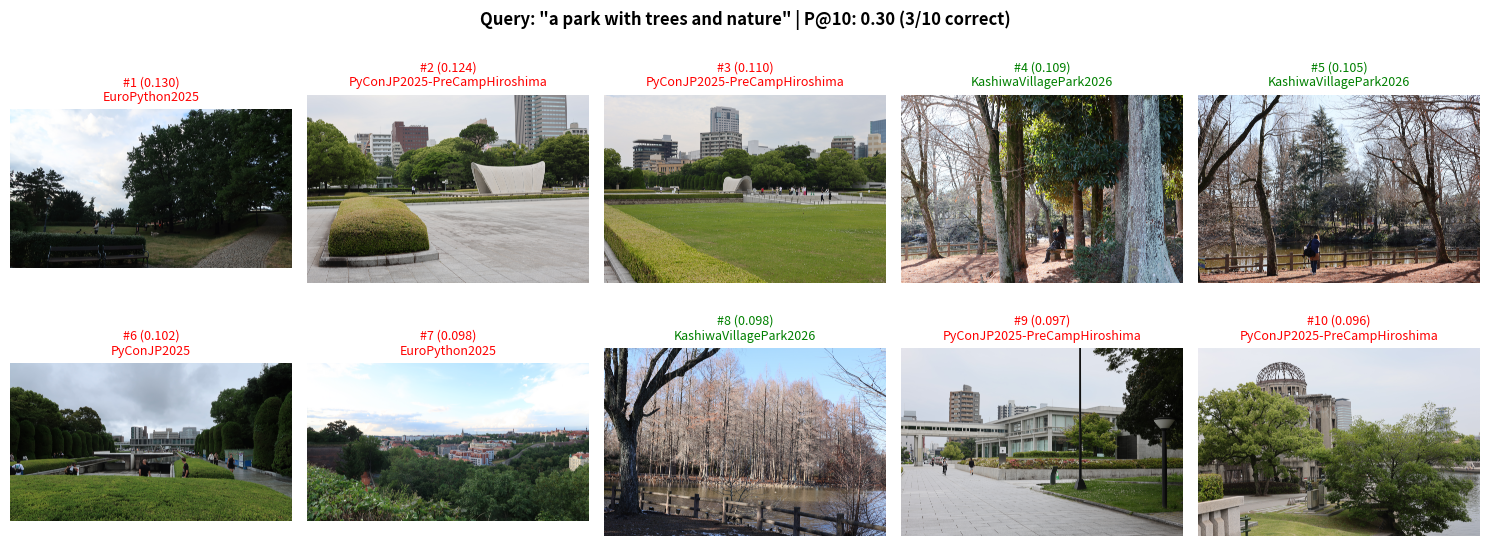

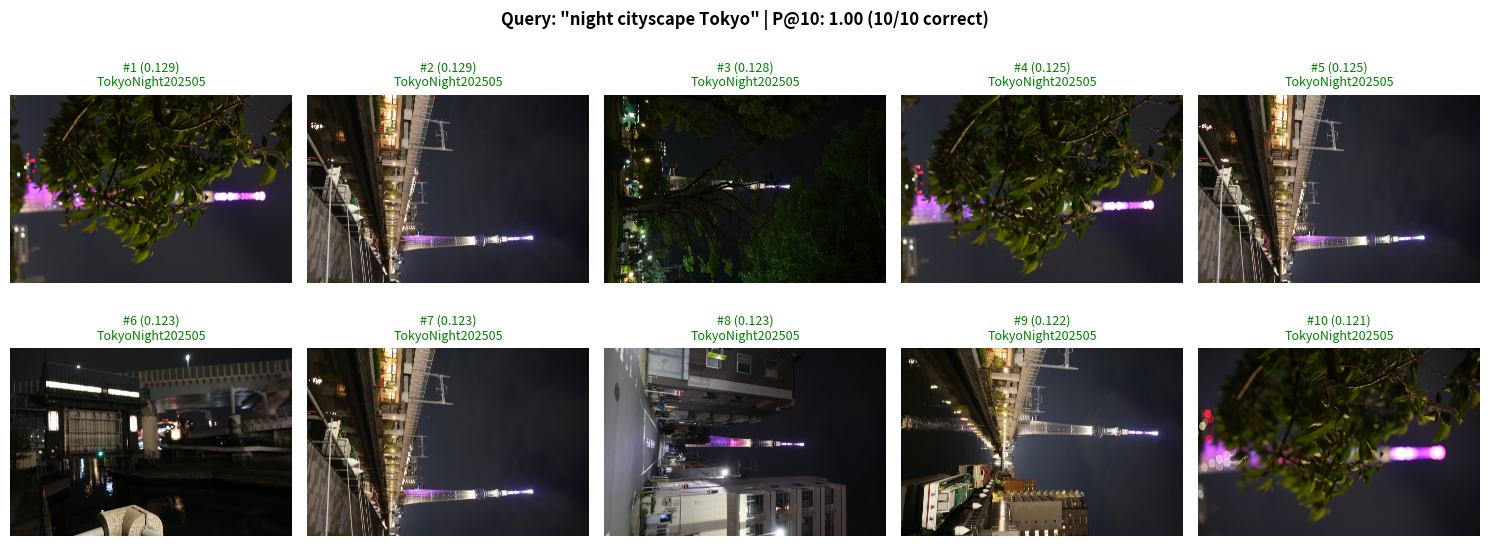

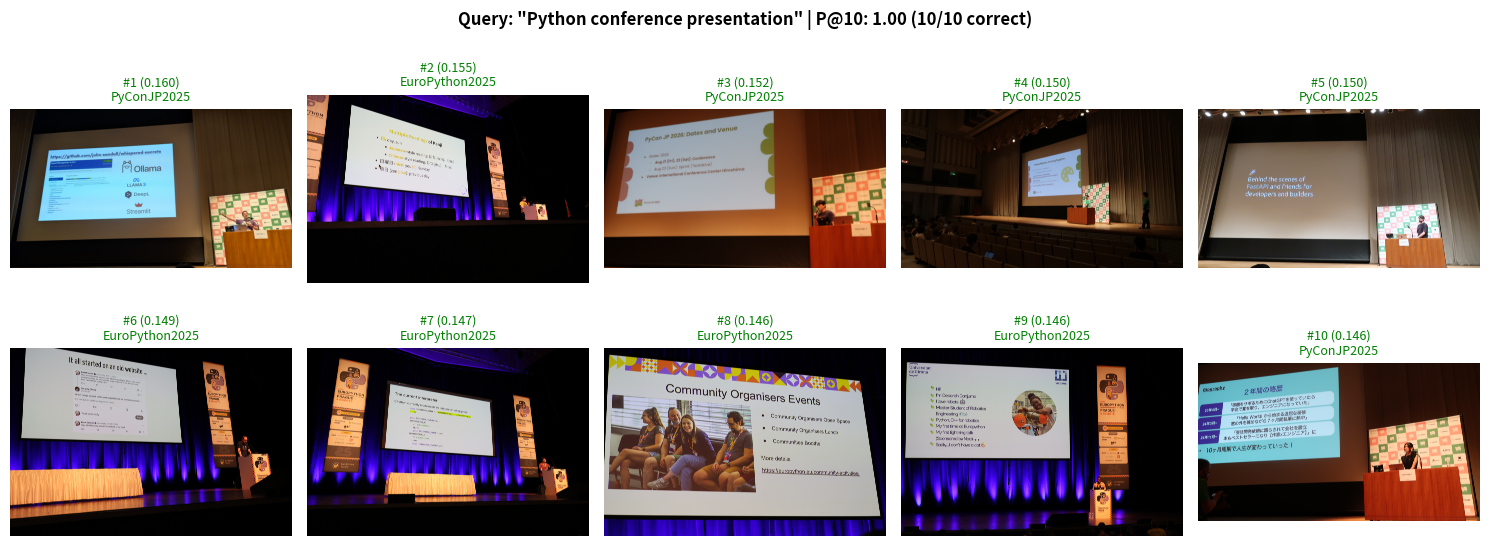

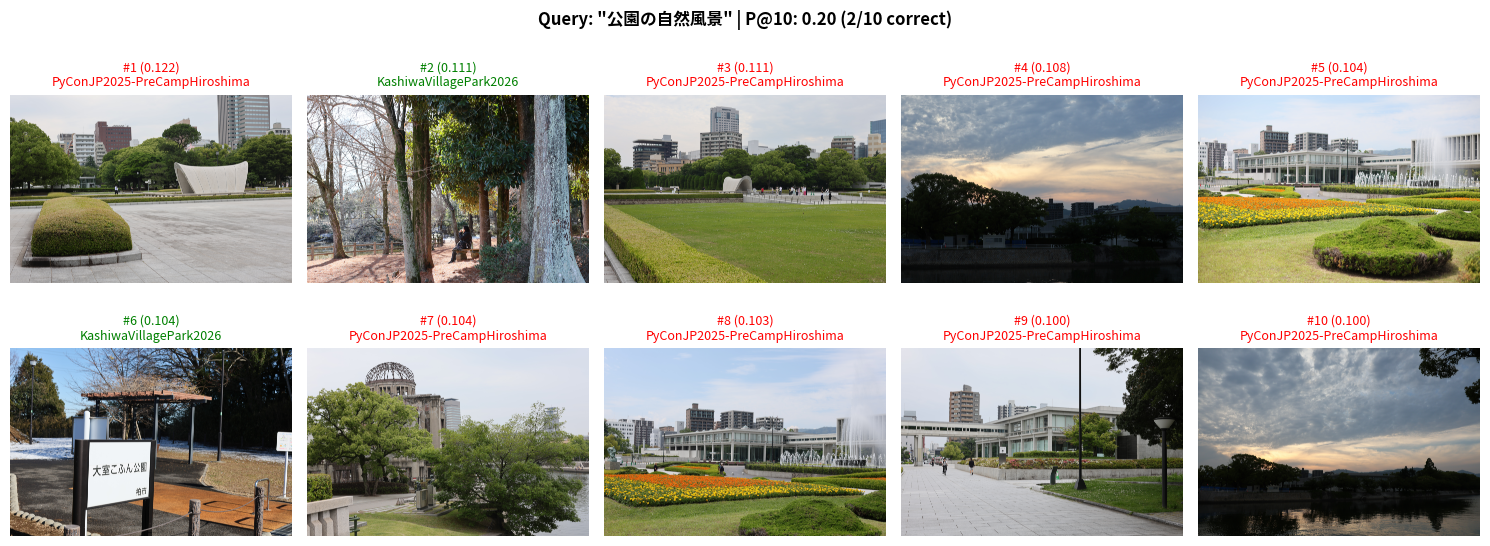

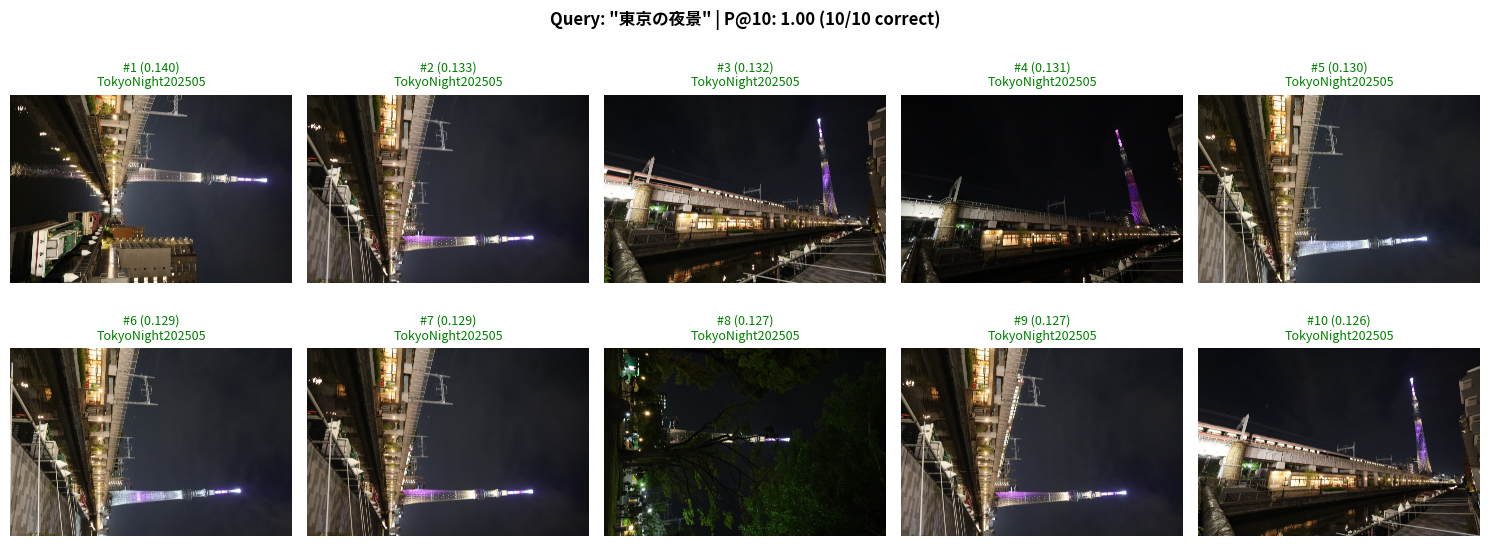

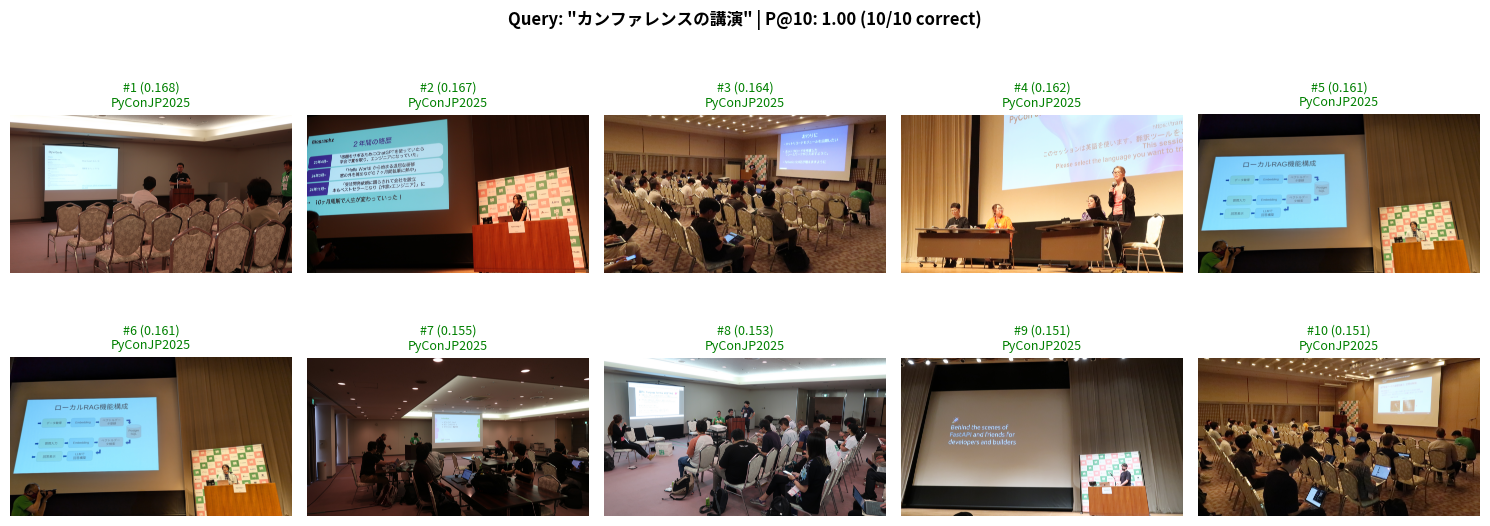

In [16]:
# いくつかのクエリの検索結果を可視化
sample_queries = [
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"]},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"]},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"]},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"]},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
]

for sq in sample_queries:
    fig = visualize_search_results(sq["query"], sq["expected_categories"], k=10)
    plt.show()
    print()

## 9. 結果の保存

In [17]:
output_data = {
    "model_name": MODEL_NAME,
    "timestamp": datetime.now().isoformat(),
    "total_queries": len(test_queries),
    "overall_metrics": overall_means.to_dict(),
    "by_language": lang_results.to_dict(),
    "by_type": type_results.to_dict(),
    "comparison": {
        "siglip1_overall": siglip1_results["overall"],
        "clip_overall": clip_results["overall"],
        "siglip2_overall": siglip2_results["overall"],
    },
    "detailed_results": results,
}

output_path = Path("../data/evaluations") / f"text_search_{MODEL_NAME.replace('/', '_')}_{datetime.now().strftime('%Y-%m-%d')}.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, default=str)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/text_search_google_siglip2-base-patch16-224_2026-02-16.json


## 10. GPUメモリのクリーンアップ

In [18]:
del embedder

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・評価・考察

SigLIP 2 Base のテキスト→画像検索性能を SigLIP 1 および CLIP-L と比較した。

### 実験結果

| 指標 | SigLIP 2 Base | SigLIP 1 | CLIP-L |
|------|:---:|:---:|:---:|
| **MRR 全体** | 0.792 | 0.819 | **0.861** |
| **MRR 英語** | 0.866 | 0.826 | **0.875** |
| **MRR 日本語** | 0.644 | **0.806** | 0.833 |
| **P@1 全体** | 0.667 | 0.722 | **0.778** |

### 考察

1. **SigLIP 2 Base の日本語テキスト検索は意外にも低い**
   - JA MRR 0.644 は SigLIP 1 の 0.806 よりも大幅に低い
   - Gemma BPE トークナイザーによりトークン化自体は改善されたが、Base モデルの学習データや
     テキスト-画像の整合性学習が十分でない可能性がある
   - 特に「公園の自然風景」(MRR=0.50)、「緑の木々」(MRR=0.25)、「夜の街」(MRR=0.11) が低い

2. **英語検索は SigLIP 1 より改善**
   - EN MRR 0.866 は SigLIP 1（0.826）を上回り、CLIP-L（0.875）に迫る
   - 英語においては SigLIP 2 のテキスト理解能力が向上している

3. **CLIP-L が全体的に最良**
   - MRR 全体 (0.861)、英語 (0.875)、日本語 (0.833) のすべてで最高
   - 768次元で安定した性能を発揮

4. **SigLIP 2 Base の日本語性能低下の仮説**
   - SigLIP 2 は 109 言語の WebLI データで訓練されており、日本語テキストの分布が
     SigLIP 1 とは異なる可能性がある
   - Base モデルの容量（8600万パラメータ）では多言語対応の負荷が高い
   - → Notebook 63 で Large / So400m モデルの日本語性能を確認する（容量増加で改善する可能性）

5. **重要な示唆: モデルサイズと日本語性能の関係**
   - 多言語モデルでは、Base サイズだと各言語のカバレッジが不十分になりがち
   - 日本語テキスト検索を重視する場合は、より大きなモデルが必要と予想される